In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import sys
import os

# Get the parent directory and add it to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import dem
from dem.models.components.mlp import MyMLP


from dem.energies.gmm_energy import GMM

/network/scratch/b/bosejoey/micromamba/envs/dem/lib/python3.10/site-packages/torchmetrics/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:

from dem.models.components.clipper import Clipper
from dem.models.components.noise_schedules import LinearNoiseSchedule
from dem.energies.base_prior import Prior

beta = torch.tensor(0.2).to(device)
noise_schedule = LinearNoiseSchedule(beta)
clipper = Clipper(
    should_clip_scores=False, should_clip_log_rewards=False, max_score_norm=50
)

prior = Prior(dim=2, device=device, scale = noise_schedule.h(1) ** 0.5)

In [5]:
import abc

class Schedule_base(metaclass=abc.ABCMeta):
    """Abstract base class from which all log densities should inherit."""

    def __init__(self):
        pass

    def __call__(self, x):
        outf = self.tt(x)
        doutf = self.dtt(x)
        
        return outf, doutf

    @abc.abstractmethod
    def tt(self, x): 
        pass

    @abc.abstractmethod
    def dtt(self, x): 
        pass

class CosSchedule(Schedule_base):
    def __init__(self):
        super().__init__()
    def tt(self,t):
        out = 0.5*(1.0-torch.cos(torch.pi*t))
        return out

    def dtt(self,t):
        out = (0.5*torch.pi*torch.sin(torch.pi*t))
        return out

class LinearSchedule(Schedule_base):
    def __init__(self):
        super().__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def tt(self, t):
        out = t 
        return out

    def dtt(self, t):
        out = torch.tensor(1.0).to(self.device)
        return out

In [7]:
import torch
from torch.autograd.functional import jacobian

class ReverseODE(torch.nn.Module):
    def __init__(self, drift, noise_schedule, prior, target, clipper, schedule, resample_threshold=0.98):
        super().__init__()
        self.drift = drift
        self.noise_schedule = noise_schedule
        self.prior = prior
        self.target = target
        self.clipper = clipper
        self.schedule = schedule
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.resample_threshold = resample_threshold
    
    def f(self, t, x):
        with torch.enable_grad():
            if t.dim() == 0:
                # repeat the same time for all points if we have a scalar time
                t = t * torch.ones(x.shape[0]).to(device)

            return self.drift(t, x)
        
    def divergence(self, t, x, vectorfield):
        # compute the divergence of the flow field
        def _func_sum(t_in, x_in):
            return vectorfield(t_in, x_in).sum(dim=0) # sum over the batches
        out= jacobian(_func_sum, (t, x),create_graph =True,vectorize=True)
        spatial_grad = out[1]
        div = spatial_grad.diagonal(offset=0, dim1=-1, dim2=-3).sum(-1)
        return div
    
    def energy_interpolation(self, t, x):
        with torch.enable_grad():
            t = t * torch.ones(x.shape[0]).to(self.device)
            x.requires_grad_(True)
            outf, doutf = self.schedule(t)
            logtarget = self.target(x)
            logprior = self.prior.log_prob(x)
            energy_interpolation = outf * logtarget + (1-outf) * logprior
            return energy_interpolation.squeeze()
        
    def log_weight_step(self, w, x, t, dt):
        with torch.enable_grad():
            t = t * torch.ones(x.shape[0]).to(self.device)
            x.requires_grad_(True)
            outf, doutf = self.schedule(t)
            logtarget = self.target(x)
            logprior = self.prior.log_prob(x)
            partial_Ht = - (doutf * logtarget  - doutf * logprior)
           
            transport_div = self.divergence(t, x, self.drift)
            nabla_Ht = -1 * jacobian(self.energy_interpolation, (t, x),create_graph =True,vectorize=True)[1]
            nabla_Ht_div = nabla_Ht.diagonal(offset=0, dim1=-1, dim2=-3).sum(-1)

        term1 = (self.drift(t, x) * nabla_Ht_div[:, None]).sum(axis=1)
        
        # Equation in Algo 1 of NETS paper
        dw = (-partial_Ht - term1 + transport_div) * dt
        w = w + dw
        return w
    
    def resample(self, samples, weights):
        # Check if weights are blowing up (using effective sample size as a metric)
        # Calculate effective sample size
        ess = torch.exp(weights).sum()**2 / torch.exp(2 * weights).sum()
        ess_ratio = ess / weights.shape[0]
        
        # Only resample if effective sample size is above threshold (e.g., 0.5)
        # This prevents resampling when weights are degenerate
        if ess_ratio > self.resample_threshold:
            # Convert weights to probabilities (normalize)
            # Add small epsilon to avoid division by zero
            epsilon = 1e-8
            probs = torch.exp(weights) + epsilon
            probs = probs / probs.sum()
            
            # Perform importance sampling resampling
            # Sample indices based on weights
            num_samples = weights.shape[0]
            indices = torch.multinomial(probs, num_samples, replacement=True)
            
            # Resample the final particles based on the sampled indices
            resampled_samples = samples[indices]
            weights = torch.zeros_like(weights)
        else:
            resampled_samples = samples
            weights = weights

        return resampled_samples, weights
    
    def euler_step(self, t, x, dt):
        drift = self.f(t, x) * dt
        x = x + drift
        return x
    
    def sample(self, x0, dt, end_time, device=None, num_samples=None, compute_weight=False):
        """
        Sample from the ODE using Euler method.
        
        Args:
            x0: initial positions
            num_steps: number of integration steps
            dt: time step size
            device: device to run on
            
        Returns:
            samples: trajectory of samples
        """

        if device is None:
            device = x0.device
        
        if x0 is None:
            x = self.prior.sample(num_samples)
        else:
            x = x0

        samples = [x]
        w = torch.zeros(x.shape[0]).to(self.device)
        weights = [w]
        start_time = torch.tensor(0.0).to(self.device)
        delta = end_time - start_time
        num_integration_steps = int(torch.abs(delta) / dt)
        times = torch.linspace(start_time, end_time, num_integration_steps + 1, device=x.device)[:-1]
       
        for t in times:
            x = self.euler_step(t, x, dt)
            if compute_weight:
                w = self.log_weight_step(w, x, t, dt)
                x, w = self.resample(x, w)
                weights.append(w)

            samples.append(x)
        
        return torch.stack(samples)


class LangevinSDE(torch.nn.Module):
    """
    Langevin SDE implementation for sampling from energy functions.
    
    The Langevin SDE is given by:
    dx = -∇E(x)dt + √(2β) dW
    
    where E(x) is the energy function, β is the inverse temperature,
    and W is a Wiener process.
    """
    
    def __init__(self, beta=1.0, schedule=None, target=None, prior=None, vel=None, clipper=None, resample_threshold=0.98):
        super().__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.beta = torch.tensor(beta).to(self.device)
        self.schedule = schedule
        self.target = target
        self.prior = prior
        self.vel = vel
        self.clipper = clipper
        self.resample_threshold = resample_threshold
    
    def f(self, t, x):
        """
        Drift term: f(t, x) = -∇E(x)
        
        Args:
            t: time (not used in Langevin dynamics)
            x: current position
            
        Returns:
            drift: -∇E(x)
        """
        
        with torch.enable_grad():
            outf, doutf = self.schedule(t)
            x.requires_grad_(True)
            energy_interpolation = outf * self.target(x) + (1-outf) * self.prior.log_prob(x)
            nabla_Ht = torch.autograd.grad(energy_interpolation.sum(), x, create_graph=True)[0]
            nabla_Ht = self.clipper.clip_scores(nabla_Ht)
            drift = nabla_Ht
            if self.vel is not None:    
                transport_drift = self.vel(t, x)
            else:
                transport_drift = torch.zeros_like(x)
        return drift + transport_drift
    
    def g(self, x):
        """
        Diffusion term: g(t, x) = √(2β)
        
        Args:
            t: time (not used in Langevin dynamics)
            x: current position
            
        Returns:
            diffusion: √(2β) * ones_like(x)
        """
        diffusion = torch.sqrt(2.0 * self.beta) * torch.ones_like(x)
        return diffusion
    
    def divergence(self, t, x, vectorfield):
        # compute the divergence of the flow field
        def _func_sum(t_in, x_in):
            return vectorfield(t_in, x_in).sum(dim=0) # sum over the batches
        out= jacobian(_func_sum, (t, x),create_graph =True,vectorize=True)
        spatial_grad = out[1]
        div = spatial_grad.diagonal(offset=0, dim1=-1, dim2=-3).sum(-1)
        return div

    def euler_maruyama_step(self, t, x, dt):
        t = t * torch.ones(x.shape[0]).to(self.device)
        drift = self.f(t, x)
        diffusion = self.g(x)
        dW = torch.randn_like(x) * torch.sqrt(dt)
        x = x + drift * dt + diffusion * dW
        return x
    
    def energy_interpolation(self, t, x):
        with torch.enable_grad():
            t = t * torch.ones(x.shape[0]).to(self.device)
            x.requires_grad_(True)
            outf, doutf = self.schedule(t)
            logtarget = self.target(x)
            logprior = self.prior.log_prob(x)
            energy_interpolation = outf * logtarget + (1-outf) * logprior
            return energy_interpolation.squeeze()
        
    def log_weight_step(self, w, x, t, dt):
        with torch.enable_grad():
            t = t * torch.ones(x.shape[0]).to(self.device)
            x.requires_grad_(True)
            outf, doutf = self.schedule(t)
            logtarget = self.target(x)
            logprior = self.prior.log_prob(x)
            partial_Ht = - (doutf * logtarget  - doutf * logprior)
           
            transport_div = self.divergence(t, x, self.vel)
            nabla_Ht = -1*jacobian(self.energy_interpolation, (t, x),create_graph =True,vectorize=True)[1]
            nabla_Ht_div = nabla_Ht.diagonal(offset=0, dim1=-1, dim2=-3).sum(-1)

        term1 = (self.vel(t, x) * nabla_Ht_div[:, None]).sum(axis=1)
        
        # Equation in Algo 1 of NETS paper
        dw = (-partial_Ht - term1 + transport_div) * dt
        w = w + dw
        return w
    
    def resample(self, samples, weights):
        # Check if weights are blowing up (using effective sample size as a metric)
        # Calculate effective sample size
        ess = torch.exp(weights).sum()**2 / torch.exp(2 * weights).sum()
        ess_ratio = ess / weights.shape[0]
        
        # Only resample if effective sample size is above threshold (e.g., 0.5)
        # This prevents resampling when weights are degenerate
        if ess_ratio > self.resample_threshold:
            # Convert weights to probabilities (normalize)
            # Add small epsilon to avoid division by zero
            epsilon = 1e-8
            probs = torch.exp(weights) + epsilon
            probs = probs / probs.sum()
            
            # Perform importance sampling resampling
            # Sample indices based on weights
            num_samples = weights.shape[0]
            indices = torch.multinomial(probs, num_samples, replacement=True)
            
            # Resample the final particles based on the sampled indices
            resampled_samples = samples[indices]
            weights = torch.zeros_like(weights)
        else:
            resampled_samples = samples
            weights = weights

        return resampled_samples, weights
    
    def sample(self, x0, dt, end_time, device=None, num_samples=None, compute_weight=False):
        """
        Sample from the Langevin SDE using Euler-Maruyama method.
        
        Args:
            x0: initial positions
            num_steps: number of integration steps
            dt: time step size
            device: device to run on
            
        Returns:
            samples: trajectory of samples
        """

        if device is None:
            device = x0.device
        
        if x0 is None:
            x = self.prior.sample(num_samples)
        else:
            x = x0

        samples = [x]
        w = torch.zeros(x.shape[0]).to(self.device)
        weights = [w]
        start_time = torch.tensor(0.0).to(self.device)
        delta = end_time - start_time
        num_integration_steps = int(torch.abs(delta) / dt)
        times = torch.linspace(start_time, end_time, num_integration_steps + 1, device=x.device)[:-1]
       
        for t in times:
            x = self.euler_maruyama_step(t, x, dt)
            if compute_weight:
                w = self.log_weight_step(w, x, t, dt)
                x, w = self.resample(x, w)
                weights.append(w)

            samples.append(x)
        
        return torch.stack(samples)

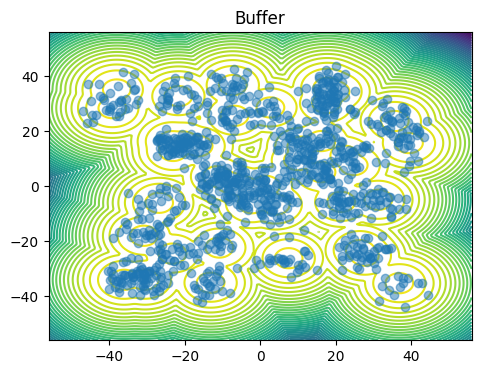

In [10]:
clipper = Clipper(
    should_clip_scores=False, should_clip_log_rewards=False, max_score_norm=50
)
target = GMM(dimensionality=2,
             n_mixes=40,
             loc_scaling= 40,
             log_var_scaling=1.0,
             device=device,
             should_unnormalize=True)

vectorfield = MyMLP().to(device)
optimizer = Adam(vectorfield.parameters(), lr=1e-3)
weighted = False
schedule = LinearSchedule()
langevin_sde = LangevinSDE(beta=1.0, prior=prior, target=target, clipper=clipper, schedule=schedule)

dt = torch.tensor(1.0 / 512).to(device)
t_init,t_end = torch.tensor(0.0).to(device), torch.tensor(1.0).to(device)
samples = langevin_sde.sample(x0=None, dt=dt, end_time=t_end, device=device, num_samples=1_000, compute_weight=False)
samples_energy = target(samples[-1])
target.get_dataset_fig(target.unnormalize(samples[-1]))
plt.show()


In [11]:
def divergence(t, x, vectorfield):
    # compute the divergence of the flow field
    def _func_sum(t_in, x_in):
        return vectorfield(t_in, x_in).sum(dim=0) # sum over the batches
    out=jacobian(_func_sum, (t, x),create_graph =True,vectorize=True)
    spatial_grad = out[1]
    div = spatial_grad.diagonal(offset=0, dim1=-1, dim2=-3).sum(-1)
    return div

def compute_pf_loss(x, t, schedule, target, prior, vectorfield, lagrange_multiplier=1.0, compute_kinetic_energy=False):    
    outf, doutf = schedule(t)
    x.requires_grad_(True)
    logtarget = target(x)
    dlogtarget = -1 * torch.autograd.grad(logtarget.sum(), x, create_graph=True)[0]
    logprior = prior.log_prob(x)
    dlogprior = - 1* torch.autograd.grad(logprior.sum(), x, create_graph=True)[0]
    score = outf * dlogtarget + (1-outf) * dlogprior
    score = clipper.clip_scores(score)  

    t_repeat = t.repeat(x.shape[0], 1)
    vel = vectorfield(t_repeat, x)
    div = divergence(t_repeat, x, vectorfield)
    inner_prod = (score*vel).sum(axis=1)

    term1 = (inner_prod - div).pow(2)
    partial_Ht = - (doutf * logtarget  - doutf * logprior)
    nabla_partial_Ht = torch.autograd.grad(partial_Ht.sum(), x, create_graph=True)[0]
    
    term2 = 2* (nabla_partial_Ht.squeeze() * vel).sum(axis=1)

    if compute_kinetic_energy:
        kinetic_energy = kinetic_energy_loss(vel)
        loss = (term1 + term2) + lagrange_multiplier * kinetic_energy
    else:
        loss = (term1 + term2)

    return loss

def generate_samples_ode(reverse_ode, num_samples):
    x = prior.sample(num_samples)
    delta = t_end - t_init
    num_integration_steps = int(torch.abs(delta) / dt)
    times = torch.linspace(t_init, t_end, num_integration_steps + 1, device=device)[:-1]
    for t in times:
        drift = reverse_ode.f(t, x) * dt
        x = x + drift
    return x

def kinetic_energy_loss(vel):
    """
    Computes the mean kinetic energy of the vectorfield at points x and time t.
    Kinetic energy is defined as 0.5 * ||v||^2, where v is the vectorfield output.
    """
    kinetic_energy = 0.5 * (vel ** 2).sum(dim=1)
    return kinetic_energy.mean()


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0 | Time 0.000000 | Loss 4.042130
Epoch 0 | Time 0.001953 | Loss -17.725632
Epoch 0 | Time 0.003906 | Loss -41.003769
Epoch 0 | Time 0.005859 | Loss -53.047798
Epoch 0 | Time 0.007812 | Loss -71.522926
Epoch 0 | Time 0.009766 | Loss -81.855774
Epoch 0 | Time 0.011719 | Loss -110.939926
Epoch 0 | Time 0.013672 | Loss -123.066986
Epoch 0 | Time 0.015625 | Loss -129.232620
Epoch 0 | Time 0.017578 | Loss -136.636292
Epoch 0 | Time 0.019531 | Loss -119.953514
Epoch 0 | Time 0.021484 | Loss -124.278175
Epoch 0 | Time 0.023438 | Loss -114.387680
Epoch 0 | Time 0.025391 | Loss -89.741531
Epoch 0 | Time 0.027344 | Loss -74.485909
Epoch 0 | Time 0.029297 | Loss -73.910210
Epoch 0 | Time 0.031250 | Loss -55.473545
Epoch 0 | Time 0.033203 | Loss -25.321659
Epoch 0 | Time 0.035156 | Loss -49.967224
Epoch 0 | Time 0.037109 | Loss -42.802856
Epoch 0 | Time 0.039062 | Loss -45.643570
Epoch 0 | Time 0.041016 | Loss -47.004616
Epoch 0 | Time 0.042969 | Loss -21.084507
Epoch 0 | Time 0.044922 | Los

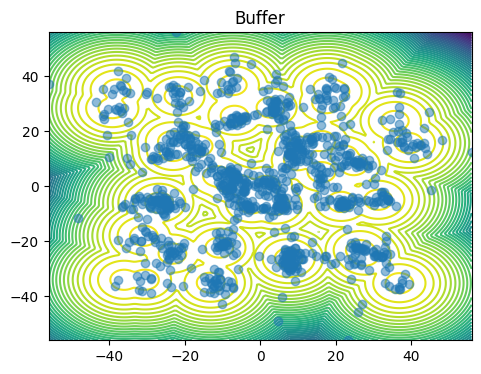

  1%|          | 1/100 [00:08<14:11,  8.60s/it]

Epoch 1 | Time 0.000000 | Loss -76.732681
Epoch 1 | Time 0.001953 | Loss -86.558640
Epoch 1 | Time 0.003906 | Loss -105.134270
Epoch 1 | Time 0.005859 | Loss -130.442947
Epoch 1 | Time 0.007812 | Loss -165.971115
Epoch 1 | Time 0.009766 | Loss -218.528000
Epoch 1 | Time 0.011719 | Loss -260.327332
Epoch 1 | Time 0.013672 | Loss -257.569244
Epoch 1 | Time 0.015625 | Loss -235.735718
Epoch 1 | Time 0.017578 | Loss -172.074158
Epoch 1 | Time 0.019531 | Loss -64.085480
Epoch 1 | Time 0.021484 | Loss -75.947311
Epoch 1 | Time 0.023438 | Loss -113.606689
Epoch 1 | Time 0.025391 | Loss -110.961044
Epoch 1 | Time 0.027344 | Loss -91.700111
Epoch 1 | Time 0.029297 | Loss -92.641708
Epoch 1 | Time 0.031250 | Loss -97.584396
Epoch 1 | Time 0.033203 | Loss -76.348557
Epoch 1 | Time 0.035156 | Loss -61.724968
Epoch 1 | Time 0.037109 | Loss -55.814568
Epoch 1 | Time 0.039062 | Loss -58.277843
Epoch 1 | Time 0.041016 | Loss -55.060452
Epoch 1 | Time 0.042969 | Loss -53.846111
Epoch 1 | Time 0.044922 

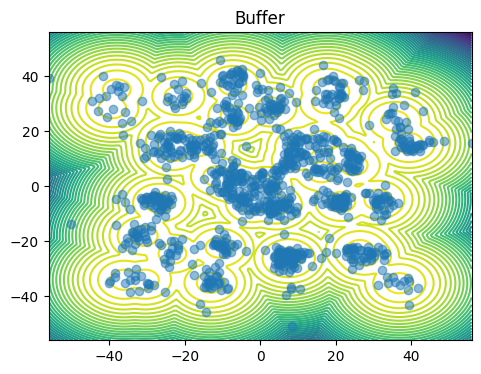

  2%|▏         | 2/100 [00:16<13:43,  8.40s/it]

Epoch 2 | Time 0.000000 | Loss -89.386421
Epoch 2 | Time 0.001953 | Loss -100.104301
Epoch 2 | Time 0.003906 | Loss -114.041885
Epoch 2 | Time 0.005859 | Loss -143.569763
Epoch 2 | Time 0.007812 | Loss -176.635147
Epoch 2 | Time 0.009766 | Loss -201.247406
Epoch 2 | Time 0.011719 | Loss -210.200638
Epoch 2 | Time 0.013672 | Loss -184.027649
Epoch 2 | Time 0.015625 | Loss -189.608643
Epoch 2 | Time 0.017578 | Loss -195.272156
Epoch 2 | Time 0.019531 | Loss -172.250885
Epoch 2 | Time 0.021484 | Loss -134.466965
Epoch 2 | Time 0.023438 | Loss -113.110519
Epoch 2 | Time 0.025391 | Loss -106.602737
Epoch 2 | Time 0.027344 | Loss -113.540024
Epoch 2 | Time 0.029297 | Loss -80.385948
Epoch 2 | Time 0.031250 | Loss -64.913826
Epoch 2 | Time 0.033203 | Loss -73.239944
Epoch 2 | Time 0.035156 | Loss -87.654991
Epoch 2 | Time 0.037109 | Loss -71.900406
Epoch 2 | Time 0.039062 | Loss -65.451340
Epoch 2 | Time 0.041016 | Loss -67.225906
Epoch 2 | Time 0.042969 | Loss -63.233727
Epoch 2 | Time 0.044

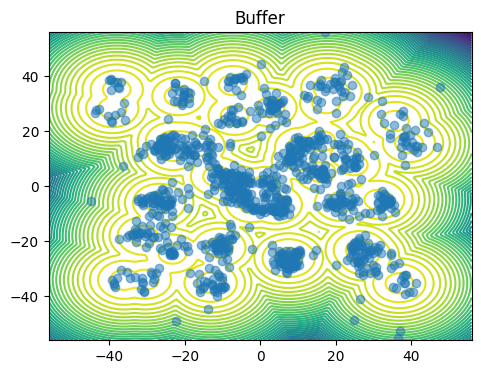

  3%|▎         | 3/100 [00:25<13:24,  8.29s/it]

Epoch 3 | Time 0.000000 | Loss -90.341934
Epoch 3 | Time 0.001953 | Loss -103.339203
Epoch 3 | Time 0.003906 | Loss -123.211449
Epoch 3 | Time 0.005859 | Loss -152.378830
Epoch 3 | Time 0.007812 | Loss -193.178009
Epoch 3 | Time 0.009766 | Loss -220.236450
Epoch 3 | Time 0.011719 | Loss -246.564026
Epoch 3 | Time 0.013672 | Loss -263.036835
Epoch 3 | Time 0.015625 | Loss -262.855957
Epoch 3 | Time 0.017578 | Loss -199.581390
Epoch 3 | Time 0.019531 | Loss -164.501617
Epoch 3 | Time 0.021484 | Loss -127.260956
Epoch 3 | Time 0.023438 | Loss -86.524536
Epoch 3 | Time 0.025391 | Loss -94.108986
Epoch 3 | Time 0.027344 | Loss -96.373344
Epoch 3 | Time 0.029297 | Loss -112.624641
Epoch 3 | Time 0.031250 | Loss -92.726273
Epoch 3 | Time 0.033203 | Loss -96.618713
Epoch 3 | Time 0.035156 | Loss -92.867401
Epoch 3 | Time 0.037109 | Loss -78.472458
Epoch 3 | Time 0.039062 | Loss -79.568481
Epoch 3 | Time 0.041016 | Loss -67.983383
Epoch 3 | Time 0.042969 | Loss -66.637894
Epoch 3 | Time 0.04492

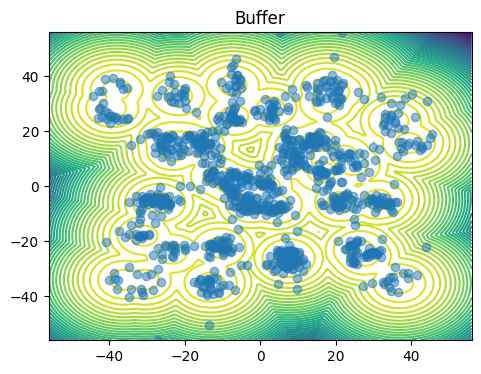

  4%|▍         | 4/100 [00:33<13:05,  8.18s/it]

Epoch 4 | Time 0.000000 | Loss -90.980118
Epoch 4 | Time 0.001953 | Loss -100.682068
Epoch 4 | Time 0.003906 | Loss -118.431885
Epoch 4 | Time 0.005859 | Loss -143.584961
Epoch 4 | Time 0.007812 | Loss -165.289856
Epoch 4 | Time 0.009766 | Loss -194.936203
Epoch 4 | Time 0.011719 | Loss -214.672028
Epoch 4 | Time 0.013672 | Loss -226.701294
Epoch 4 | Time 0.015625 | Loss -214.311890
Epoch 4 | Time 0.017578 | Loss -216.229034
Epoch 4 | Time 0.019531 | Loss -192.639496
Epoch 4 | Time 0.021484 | Loss -178.485825
Epoch 4 | Time 0.023438 | Loss -151.775757
Epoch 4 | Time 0.025391 | Loss -124.512924
Epoch 4 | Time 0.027344 | Loss -112.648155
Epoch 4 | Time 0.029297 | Loss -101.454987
Epoch 4 | Time 0.031250 | Loss -100.283859
Epoch 4 | Time 0.033203 | Loss -102.039627
Epoch 4 | Time 0.035156 | Loss -93.495995
Epoch 4 | Time 0.037109 | Loss -99.010437
Epoch 4 | Time 0.039062 | Loss -86.416656
Epoch 4 | Time 0.041016 | Loss -79.639160
Epoch 4 | Time 0.042969 | Loss -79.812553
Epoch 4 | Time 0.

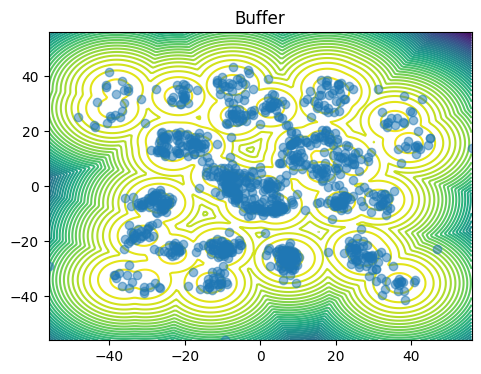

  5%|▌         | 5/100 [00:41<12:51,  8.12s/it]

Epoch 5 | Time 0.000000 | Loss -91.043320
Epoch 5 | Time 0.001953 | Loss -103.873398
Epoch 5 | Time 0.003906 | Loss -127.446434
Epoch 5 | Time 0.005859 | Loss -156.654144
Epoch 5 | Time 0.007812 | Loss -188.681519
Epoch 5 | Time 0.009766 | Loss -214.269485
Epoch 5 | Time 0.011719 | Loss -231.942062
Epoch 5 | Time 0.013672 | Loss -253.736176
Epoch 5 | Time 0.015625 | Loss -246.923553
Epoch 5 | Time 0.017578 | Loss -240.734192
Epoch 5 | Time 0.019531 | Loss -198.370438
Epoch 5 | Time 0.021484 | Loss -182.710968
Epoch 5 | Time 0.023438 | Loss -139.556824
Epoch 5 | Time 0.025391 | Loss -104.639542
Epoch 5 | Time 0.027344 | Loss -83.097336
Epoch 5 | Time 0.029297 | Loss -82.600365
Epoch 5 | Time 0.031250 | Loss -91.738304
Epoch 5 | Time 0.033203 | Loss -97.033852
Epoch 5 | Time 0.035156 | Loss -84.453957
Epoch 5 | Time 0.037109 | Loss -81.013069
Epoch 5 | Time 0.039062 | Loss -81.336380
Epoch 5 | Time 0.041016 | Loss -77.681839
Epoch 5 | Time 0.042969 | Loss -71.339203
Epoch 5 | Time 0.0449

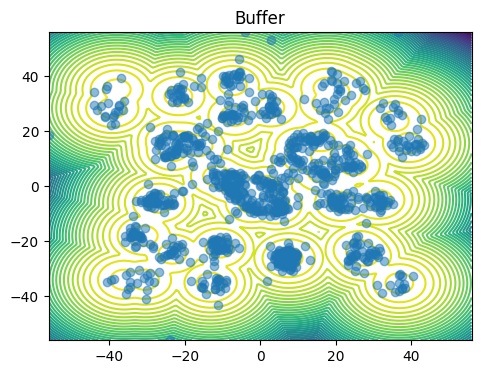

  6%|▌         | 6/100 [00:49<12:44,  8.14s/it]

Epoch 6 | Time 0.000000 | Loss -96.080795
Epoch 6 | Time 0.001953 | Loss -104.660698
Epoch 6 | Time 0.003906 | Loss -124.912857
Epoch 6 | Time 0.005859 | Loss -151.729843
Epoch 6 | Time 0.007812 | Loss -183.721512
Epoch 6 | Time 0.009766 | Loss -211.323029
Epoch 6 | Time 0.011719 | Loss -232.517853
Epoch 6 | Time 0.013672 | Loss -236.690506
Epoch 6 | Time 0.015625 | Loss -239.807465
Epoch 6 | Time 0.017578 | Loss -223.074890
Epoch 6 | Time 0.019531 | Loss -188.275024
Epoch 6 | Time 0.021484 | Loss -168.629608
Epoch 6 | Time 0.023438 | Loss -147.106384
Epoch 6 | Time 0.025391 | Loss -132.232513
Epoch 6 | Time 0.027344 | Loss -121.258560
Epoch 6 | Time 0.029297 | Loss -109.030815
Epoch 6 | Time 0.031250 | Loss -102.827484
Epoch 6 | Time 0.033203 | Loss -82.792435
Epoch 6 | Time 0.035156 | Loss -86.273956
Epoch 6 | Time 0.037109 | Loss -87.565727
Epoch 6 | Time 0.039062 | Loss -86.448288
Epoch 6 | Time 0.041016 | Loss -94.490021
Epoch 6 | Time 0.042969 | Loss -86.223351
Epoch 6 | Time 0.0

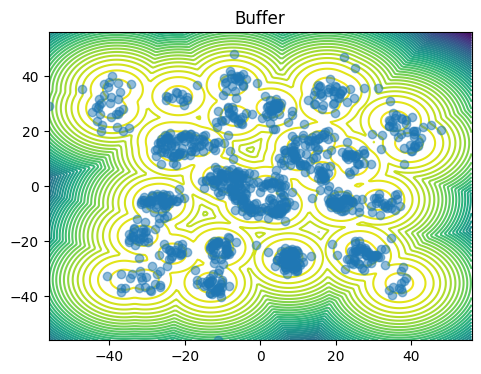

  7%|▋         | 7/100 [00:57<12:30,  8.07s/it]

Epoch 7 | Time 0.000000 | Loss -110.779175
Epoch 7 | Time 0.001953 | Loss -121.682686
Epoch 7 | Time 0.003906 | Loss -148.761810
Epoch 7 | Time 0.005859 | Loss -177.860931
Epoch 7 | Time 0.007812 | Loss -211.311905
Epoch 7 | Time 0.009766 | Loss -241.825806
Epoch 7 | Time 0.011719 | Loss -252.213531
Epoch 7 | Time 0.013672 | Loss -260.697083
Epoch 7 | Time 0.015625 | Loss -250.648254
Epoch 7 | Time 0.017578 | Loss -229.942383
Epoch 7 | Time 0.019531 | Loss -184.642548
Epoch 7 | Time 0.021484 | Loss -158.792709
Epoch 7 | Time 0.023438 | Loss -121.073654
Epoch 7 | Time 0.025391 | Loss -116.017334
Epoch 7 | Time 0.027344 | Loss -103.524750
Epoch 7 | Time 0.029297 | Loss -101.953476
Epoch 7 | Time 0.031250 | Loss -83.852585
Epoch 7 | Time 0.033203 | Loss -85.074188
Epoch 7 | Time 0.035156 | Loss -90.531113
Epoch 7 | Time 0.037109 | Loss -93.983864
Epoch 7 | Time 0.039062 | Loss -79.377190
Epoch 7 | Time 0.041016 | Loss -75.272652
Epoch 7 | Time 0.042969 | Loss -73.386154
Epoch 7 | Time 0.0

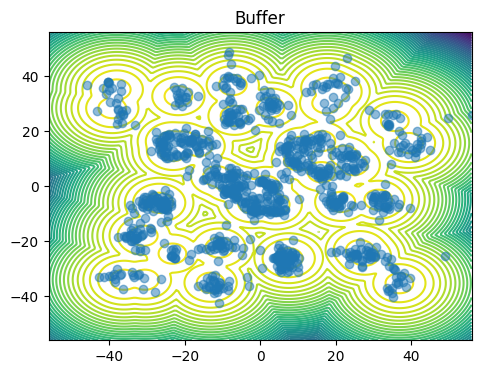

  8%|▊         | 8/100 [01:05<12:23,  8.08s/it]

Epoch 8 | Time 0.000000 | Loss -100.438248
Epoch 8 | Time 0.001953 | Loss -112.164246
Epoch 8 | Time 0.003906 | Loss -125.589310
Epoch 8 | Time 0.005859 | Loss -148.586426
Epoch 8 | Time 0.007812 | Loss -173.059296
Epoch 8 | Time 0.009766 | Loss -191.946045
Epoch 8 | Time 0.011719 | Loss -205.919830
Epoch 8 | Time 0.013672 | Loss -224.871033
Epoch 8 | Time 0.015625 | Loss -229.573761
Epoch 8 | Time 0.017578 | Loss -211.205139
Epoch 8 | Time 0.019531 | Loss -194.482483
Epoch 8 | Time 0.021484 | Loss -169.248138
Epoch 8 | Time 0.023438 | Loss -156.367828
Epoch 8 | Time 0.025391 | Loss -133.817261
Epoch 8 | Time 0.027344 | Loss -112.972244
Epoch 8 | Time 0.029297 | Loss -91.033195
Epoch 8 | Time 0.031250 | Loss -76.213951
Epoch 8 | Time 0.033203 | Loss -86.989471
Epoch 8 | Time 0.035156 | Loss -79.169952
Epoch 8 | Time 0.037109 | Loss -78.879669
Epoch 8 | Time 0.039062 | Loss -66.803726
Epoch 8 | Time 0.041016 | Loss -73.899895
Epoch 8 | Time 0.042969 | Loss -72.855705
Epoch 8 | Time 0.04

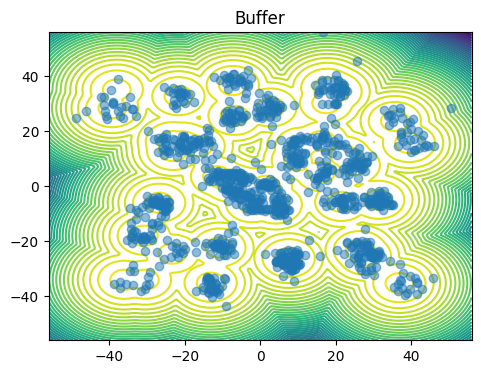

  9%|▉         | 9/100 [01:13<12:15,  8.08s/it]

Epoch 9 | Time 0.000000 | Loss -108.634354
Epoch 9 | Time 0.001953 | Loss -122.058197
Epoch 9 | Time 0.003906 | Loss -142.007019
Epoch 9 | Time 0.005859 | Loss -173.922668
Epoch 9 | Time 0.007812 | Loss -198.781738
Epoch 9 | Time 0.009766 | Loss -222.440735
Epoch 9 | Time 0.011719 | Loss -239.360199
Epoch 9 | Time 0.013672 | Loss -232.776306
Epoch 9 | Time 0.015625 | Loss -216.960648
Epoch 9 | Time 0.017578 | Loss -204.794525
Epoch 9 | Time 0.019531 | Loss -186.784454
Epoch 9 | Time 0.021484 | Loss -182.197357
Epoch 9 | Time 0.023438 | Loss -162.998566
Epoch 9 | Time 0.025391 | Loss -149.591141
Epoch 9 | Time 0.027344 | Loss -129.676514
Epoch 9 | Time 0.029297 | Loss -115.247391
Epoch 9 | Time 0.031250 | Loss -104.685806
Epoch 9 | Time 0.033203 | Loss -86.786591
Epoch 9 | Time 0.035156 | Loss -85.703049
Epoch 9 | Time 0.037109 | Loss -84.593567
Epoch 9 | Time 0.039062 | Loss -70.493759
Epoch 9 | Time 0.041016 | Loss -66.248398
Epoch 9 | Time 0.042969 | Loss -45.465206
Epoch 9 | Time 0.

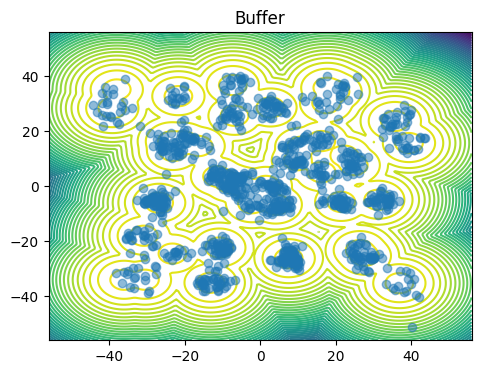

 10%|█         | 10/100 [01:21<12:10,  8.11s/it]

Epoch 10 | Time 0.000000 | Loss -116.345688
Epoch 10 | Time 0.001953 | Loss -130.292969
Epoch 10 | Time 0.003906 | Loss -155.919861
Epoch 10 | Time 0.005859 | Loss -184.201401
Epoch 10 | Time 0.007812 | Loss -220.476562
Epoch 10 | Time 0.009766 | Loss -237.224854
Epoch 10 | Time 0.011719 | Loss -250.783295
Epoch 10 | Time 0.013672 | Loss -253.309555
Epoch 10 | Time 0.015625 | Loss -238.077332
Epoch 10 | Time 0.017578 | Loss -210.484131
Epoch 10 | Time 0.019531 | Loss -187.806824
Epoch 10 | Time 0.021484 | Loss -156.834045
Epoch 10 | Time 0.023438 | Loss -147.136963
Epoch 10 | Time 0.025391 | Loss -145.803864
Epoch 10 | Time 0.027344 | Loss -112.992561
Epoch 10 | Time 0.029297 | Loss -108.137466
Epoch 10 | Time 0.031250 | Loss -83.065994
Epoch 10 | Time 0.033203 | Loss -66.967926
Epoch 10 | Time 0.035156 | Loss -78.862823
Epoch 10 | Time 0.037109 | Loss -72.966248
Epoch 10 | Time 0.039062 | Loss -65.611862
Epoch 10 | Time 0.041016 | Loss -67.271210
Epoch 10 | Time 0.042969 | Loss -81.08

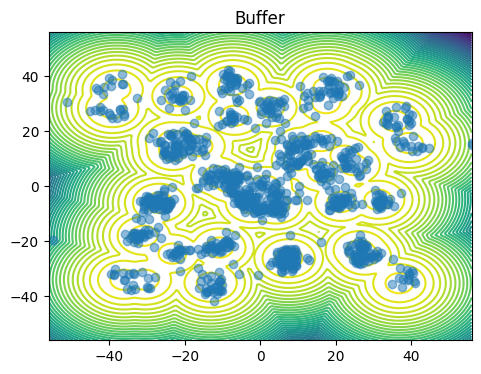

 11%|█         | 11/100 [01:29<11:57,  8.06s/it]

Epoch 11 | Time 0.000000 | Loss -120.651550
Epoch 11 | Time 0.001953 | Loss -129.223938
Epoch 11 | Time 0.003906 | Loss -148.127594
Epoch 11 | Time 0.005859 | Loss -172.888611
Epoch 11 | Time 0.007812 | Loss -197.677292
Epoch 11 | Time 0.009766 | Loss -217.705795
Epoch 11 | Time 0.011719 | Loss -227.972580
Epoch 11 | Time 0.013672 | Loss -229.628265
Epoch 11 | Time 0.015625 | Loss -238.023499
Epoch 11 | Time 0.017578 | Loss -195.212158
Epoch 11 | Time 0.019531 | Loss -151.845581
Epoch 11 | Time 0.021484 | Loss -152.964417
Epoch 11 | Time 0.023438 | Loss -149.297745
Epoch 11 | Time 0.025391 | Loss -149.011230
Epoch 11 | Time 0.027344 | Loss -139.328308
Epoch 11 | Time 0.029297 | Loss -100.642960
Epoch 11 | Time 0.031250 | Loss -81.936737
Epoch 11 | Time 0.033203 | Loss -79.120697
Epoch 11 | Time 0.035156 | Loss -90.764282
Epoch 11 | Time 0.037109 | Loss -91.765732
Epoch 11 | Time 0.039062 | Loss -75.768852
Epoch 11 | Time 0.041016 | Loss -67.444778
Epoch 11 | Time 0.042969 | Loss -76.01

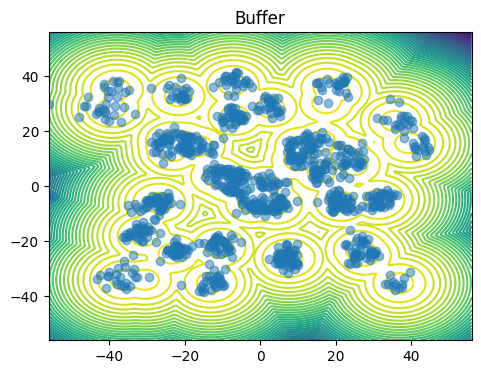

 12%|█▏        | 12/100 [01:37<11:52,  8.09s/it]

Epoch 12 | Time 0.000000 | Loss -156.052948
Epoch 12 | Time 0.001953 | Loss -177.583435
Epoch 12 | Time 0.003906 | Loss -220.025238
Epoch 12 | Time 0.005859 | Loss -265.853760
Epoch 12 | Time 0.007812 | Loss -314.842712
Epoch 12 | Time 0.009766 | Loss -341.693573
Epoch 12 | Time 0.011719 | Loss -343.593018
Epoch 12 | Time 0.013672 | Loss -322.918091
Epoch 12 | Time 0.015625 | Loss -273.112396
Epoch 12 | Time 0.017578 | Loss -215.902725
Epoch 12 | Time 0.019531 | Loss -160.986694
Epoch 12 | Time 0.021484 | Loss -133.190308
Epoch 12 | Time 0.023438 | Loss -128.522629
Epoch 12 | Time 0.025391 | Loss -132.285782
Epoch 12 | Time 0.027344 | Loss -117.951157
Epoch 12 | Time 0.029297 | Loss -128.789307
Epoch 12 | Time 0.031250 | Loss -102.291595
Epoch 12 | Time 0.033203 | Loss -110.662125
Epoch 12 | Time 0.035156 | Loss -97.864052
Epoch 12 | Time 0.037109 | Loss -103.904045
Epoch 12 | Time 0.039062 | Loss -87.403320
Epoch 12 | Time 0.041016 | Loss -79.137527
Epoch 12 | Time 0.042969 | Loss -73

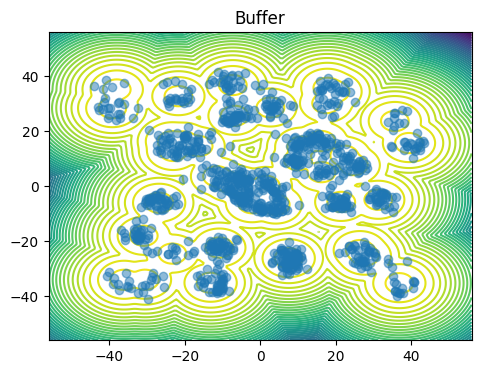

 13%|█▎        | 13/100 [01:45<11:40,  8.05s/it]

Epoch 13 | Time 0.000000 | Loss -136.901276
Epoch 13 | Time 0.001953 | Loss -154.154510
Epoch 13 | Time 0.003906 | Loss -178.715210
Epoch 13 | Time 0.005859 | Loss -216.076248
Epoch 13 | Time 0.007812 | Loss -244.559723
Epoch 13 | Time 0.009766 | Loss -270.636353
Epoch 13 | Time 0.011719 | Loss -277.180420
Epoch 13 | Time 0.013672 | Loss -284.159119
Epoch 13 | Time 0.015625 | Loss -258.717651
Epoch 13 | Time 0.017578 | Loss -243.958984
Epoch 13 | Time 0.019531 | Loss -211.180939
Epoch 13 | Time 0.021484 | Loss -179.406158
Epoch 13 | Time 0.023438 | Loss -133.500656
Epoch 13 | Time 0.025391 | Loss -118.772354
Epoch 13 | Time 0.027344 | Loss -116.278816
Epoch 13 | Time 0.029297 | Loss -112.130859
Epoch 13 | Time 0.031250 | Loss -116.638016
Epoch 13 | Time 0.033203 | Loss -99.069565
Epoch 13 | Time 0.035156 | Loss -85.109894
Epoch 13 | Time 0.037109 | Loss -82.341553
Epoch 13 | Time 0.039062 | Loss -74.767853
Epoch 13 | Time 0.041016 | Loss -76.675552
Epoch 13 | Time 0.042969 | Loss -82.5

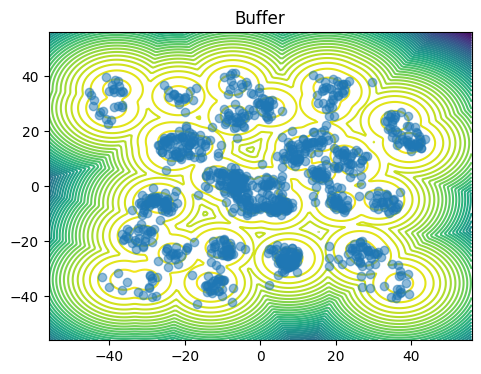

 14%|█▍        | 14/100 [01:53<11:34,  8.08s/it]

Epoch 14 | Time 0.000000 | Loss -111.901627
Epoch 14 | Time 0.001953 | Loss -125.755676
Epoch 14 | Time 0.003906 | Loss -155.125183
Epoch 14 | Time 0.005859 | Loss -186.943817
Epoch 14 | Time 0.007812 | Loss -211.647507
Epoch 14 | Time 0.009766 | Loss -245.522049
Epoch 14 | Time 0.011719 | Loss -263.784241
Epoch 14 | Time 0.013672 | Loss -278.286438
Epoch 14 | Time 0.015625 | Loss -257.163239
Epoch 14 | Time 0.017578 | Loss -220.071808
Epoch 14 | Time 0.019531 | Loss -190.106308
Epoch 14 | Time 0.021484 | Loss -153.977005
Epoch 14 | Time 0.023438 | Loss -114.499756
Epoch 14 | Time 0.025391 | Loss -93.607300
Epoch 14 | Time 0.027344 | Loss -78.255829
Epoch 14 | Time 0.029297 | Loss -61.951050
Epoch 14 | Time 0.031250 | Loss -57.312408
Epoch 14 | Time 0.033203 | Loss -69.673355
Epoch 14 | Time 0.035156 | Loss -84.661392
Epoch 14 | Time 0.037109 | Loss -88.715134
Epoch 14 | Time 0.039062 | Loss -65.271484
Epoch 14 | Time 0.041016 | Loss -72.507584
Epoch 14 | Time 0.042969 | Loss -72.10287

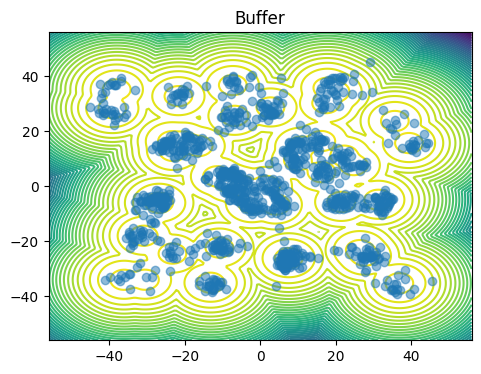

 15%|█▌        | 15/100 [02:01<11:23,  8.04s/it]

Epoch 15 | Time 0.000000 | Loss -122.957138
Epoch 15 | Time 0.001953 | Loss -139.130051
Epoch 15 | Time 0.003906 | Loss -157.299896
Epoch 15 | Time 0.005859 | Loss -188.347412
Epoch 15 | Time 0.007812 | Loss -221.070206
Epoch 15 | Time 0.009766 | Loss -239.533752
Epoch 15 | Time 0.011719 | Loss -254.932770
Epoch 15 | Time 0.013672 | Loss -249.553177
Epoch 15 | Time 0.015625 | Loss -258.008636
Epoch 15 | Time 0.017578 | Loss -242.629700
Epoch 15 | Time 0.019531 | Loss -209.370041
Epoch 15 | Time 0.021484 | Loss -175.248627
Epoch 15 | Time 0.023438 | Loss -137.160980
Epoch 15 | Time 0.025391 | Loss -129.425781
Epoch 15 | Time 0.027344 | Loss -119.577988
Epoch 15 | Time 0.029297 | Loss -117.915131
Epoch 15 | Time 0.031250 | Loss -112.446175
Epoch 15 | Time 0.033203 | Loss -98.350906
Epoch 15 | Time 0.035156 | Loss -82.832367
Epoch 15 | Time 0.037109 | Loss -87.856705
Epoch 15 | Time 0.039062 | Loss -75.784462
Epoch 15 | Time 0.041016 | Loss -68.540741
Epoch 15 | Time 0.042969 | Loss -65.9

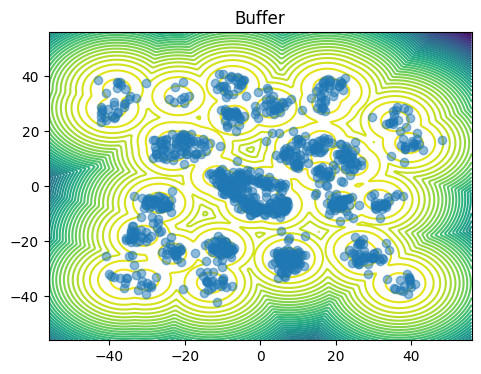

 16%|█▌        | 16/100 [02:09<11:16,  8.05s/it]

Epoch 16 | Time 0.000000 | Loss -97.149055
Epoch 16 | Time 0.001953 | Loss -112.806473
Epoch 16 | Time 0.003906 | Loss -127.054230
Epoch 16 | Time 0.005859 | Loss -150.969696
Epoch 16 | Time 0.007812 | Loss -168.523590
Epoch 16 | Time 0.009766 | Loss -190.697998
Epoch 16 | Time 0.011719 | Loss -204.298050
Epoch 16 | Time 0.013672 | Loss -204.329620
Epoch 16 | Time 0.015625 | Loss -201.610901
Epoch 16 | Time 0.017578 | Loss -206.772171
Epoch 16 | Time 0.019531 | Loss -202.305115
Epoch 16 | Time 0.021484 | Loss -193.330505
Epoch 16 | Time 0.023438 | Loss -155.529388
Epoch 16 | Time 0.025391 | Loss -153.076950
Epoch 16 | Time 0.027344 | Loss -141.976028
Epoch 16 | Time 0.029297 | Loss -126.322433
Epoch 16 | Time 0.031250 | Loss -107.416901
Epoch 16 | Time 0.033203 | Loss -88.783760
Epoch 16 | Time 0.035156 | Loss -96.830994
Epoch 16 | Time 0.037109 | Loss -98.843048
Epoch 16 | Time 0.039062 | Loss -86.915146
Epoch 16 | Time 0.041016 | Loss -52.843544
Epoch 16 | Time 0.042969 | Loss -53.29

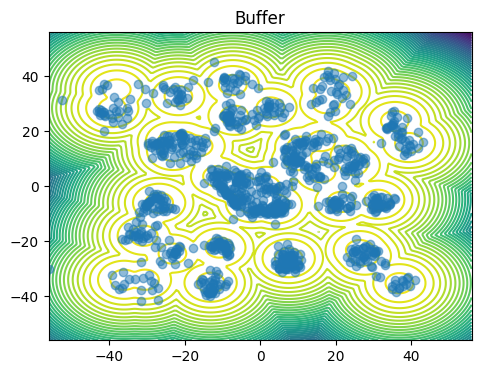

 17%|█▋        | 17/100 [02:17<11:07,  8.04s/it]

Epoch 17 | Time 0.000000 | Loss -134.502014
Epoch 17 | Time 0.001953 | Loss -145.544083
Epoch 17 | Time 0.003906 | Loss -158.969086
Epoch 17 | Time 0.005859 | Loss -185.992645
Epoch 17 | Time 0.007812 | Loss -204.060425
Epoch 17 | Time 0.009766 | Loss -220.555176
Epoch 17 | Time 0.011719 | Loss -213.870926
Epoch 17 | Time 0.013672 | Loss -214.783447
Epoch 17 | Time 0.015625 | Loss -213.380569
Epoch 17 | Time 0.017578 | Loss -204.780151
Epoch 17 | Time 0.019531 | Loss -189.688156
Epoch 17 | Time 0.021484 | Loss -154.039871
Epoch 17 | Time 0.023438 | Loss -128.562469
Epoch 17 | Time 0.025391 | Loss -129.188705
Epoch 17 | Time 0.027344 | Loss -94.918137
Epoch 17 | Time 0.029297 | Loss -91.020142
Epoch 17 | Time 0.031250 | Loss -93.891792
Epoch 17 | Time 0.033203 | Loss -78.239105
Epoch 17 | Time 0.035156 | Loss -73.400375
Epoch 17 | Time 0.037109 | Loss -86.582626
Epoch 17 | Time 0.039062 | Loss -81.403000
Epoch 17 | Time 0.041016 | Loss -73.886749
Epoch 17 | Time 0.042969 | Loss -76.1284

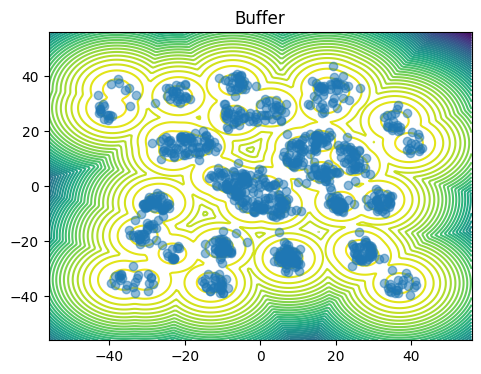

 18%|█▊        | 18/100 [02:25<10:58,  8.03s/it]

Epoch 18 | Time 0.000000 | Loss -142.750061
Epoch 18 | Time 0.001953 | Loss -160.114838
Epoch 18 | Time 0.003906 | Loss -185.156006
Epoch 18 | Time 0.005859 | Loss -213.565292
Epoch 18 | Time 0.007812 | Loss -236.158096
Epoch 18 | Time 0.009766 | Loss -254.195221
Epoch 18 | Time 0.011719 | Loss -263.935944
Epoch 18 | Time 0.013672 | Loss -259.414398
Epoch 18 | Time 0.015625 | Loss -245.655411
Epoch 18 | Time 0.017578 | Loss -227.800476
Epoch 18 | Time 0.019531 | Loss -202.916092
Epoch 18 | Time 0.021484 | Loss -181.743790
Epoch 18 | Time 0.023438 | Loss -159.427734
Epoch 18 | Time 0.025391 | Loss -146.331696
Epoch 18 | Time 0.027344 | Loss -153.987579
Epoch 18 | Time 0.029297 | Loss -134.560791
Epoch 18 | Time 0.031250 | Loss -116.021584
Epoch 18 | Time 0.033203 | Loss -105.964226
Epoch 18 | Time 0.035156 | Loss -97.367226
Epoch 18 | Time 0.037109 | Loss -106.116531
Epoch 18 | Time 0.039062 | Loss -92.081909
Epoch 18 | Time 0.041016 | Loss -82.163834
Epoch 18 | Time 0.042969 | Loss -85

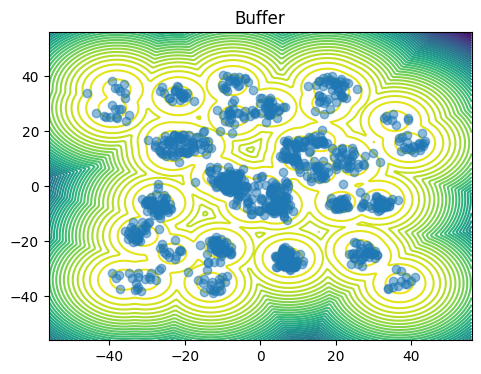

 19%|█▉        | 19/100 [02:33<10:52,  8.05s/it]

Epoch 19 | Time 0.000000 | Loss -156.079987
Epoch 19 | Time 0.001953 | Loss -166.624664
Epoch 19 | Time 0.003906 | Loss -178.938324
Epoch 19 | Time 0.005859 | Loss -205.937073
Epoch 19 | Time 0.007812 | Loss -223.495895
Epoch 19 | Time 0.009766 | Loss -232.259216
Epoch 19 | Time 0.011719 | Loss -234.692352
Epoch 19 | Time 0.013672 | Loss -221.534286
Epoch 19 | Time 0.015625 | Loss -205.099854
Epoch 19 | Time 0.017578 | Loss -186.809998
Epoch 19 | Time 0.019531 | Loss -165.393234
Epoch 19 | Time 0.021484 | Loss -154.383377
Epoch 19 | Time 0.023438 | Loss -139.634399
Epoch 19 | Time 0.025391 | Loss -150.111420
Epoch 19 | Time 0.027344 | Loss -134.474625
Epoch 19 | Time 0.029297 | Loss -117.661842
Epoch 19 | Time 0.031250 | Loss -93.579781
Epoch 19 | Time 0.033203 | Loss -85.831207
Epoch 19 | Time 0.035156 | Loss -71.438644
Epoch 19 | Time 0.037109 | Loss -75.101181
Epoch 19 | Time 0.039062 | Loss -62.050941
Epoch 19 | Time 0.041016 | Loss -58.420250
Epoch 19 | Time 0.042969 | Loss -67.19

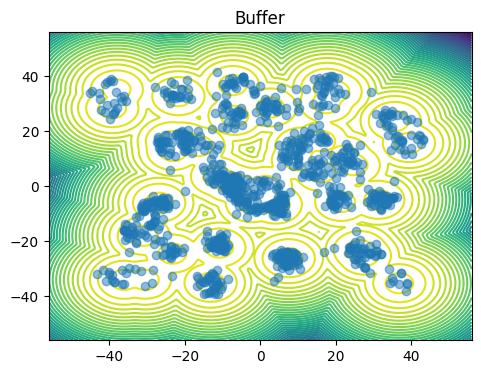

 20%|██        | 20/100 [02:41<10:40,  8.01s/it]

Epoch 20 | Time 0.000000 | Loss -155.797180
Epoch 20 | Time 0.001953 | Loss -167.695435
Epoch 20 | Time 0.003906 | Loss -191.039093
Epoch 20 | Time 0.005859 | Loss -210.501221
Epoch 20 | Time 0.007812 | Loss -227.257202
Epoch 20 | Time 0.009766 | Loss -248.332642
Epoch 20 | Time 0.011719 | Loss -240.834244
Epoch 20 | Time 0.013672 | Loss -244.898590
Epoch 20 | Time 0.015625 | Loss -225.777817
Epoch 20 | Time 0.017578 | Loss -220.266205
Epoch 20 | Time 0.019531 | Loss -171.065430
Epoch 20 | Time 0.021484 | Loss -171.819870
Epoch 20 | Time 0.023438 | Loss -159.872528
Epoch 20 | Time 0.025391 | Loss -133.553085
Epoch 20 | Time 0.027344 | Loss -135.922653
Epoch 20 | Time 0.029297 | Loss -129.667130
Epoch 20 | Time 0.031250 | Loss -108.617767
Epoch 20 | Time 0.033203 | Loss -103.085014
Epoch 20 | Time 0.035156 | Loss -87.269279
Epoch 20 | Time 0.037109 | Loss -61.474915
Epoch 20 | Time 0.039062 | Loss -67.939285
Epoch 20 | Time 0.041016 | Loss -50.696339
Epoch 20 | Time 0.042969 | Loss -60.

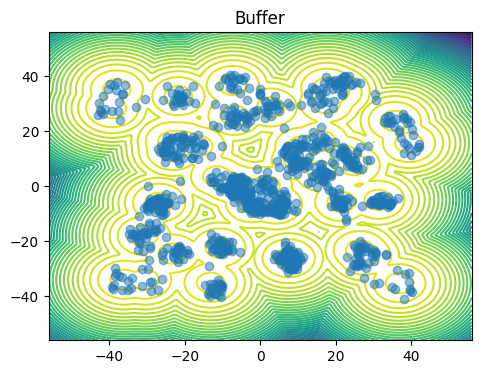

 21%|██        | 21/100 [02:49<10:34,  8.03s/it]

Epoch 21 | Time 0.000000 | Loss -152.770508
Epoch 21 | Time 0.001953 | Loss -158.479019
Epoch 21 | Time 0.003906 | Loss -179.452179
Epoch 21 | Time 0.005859 | Loss -201.668198
Epoch 21 | Time 0.007812 | Loss -217.969666
Epoch 21 | Time 0.009766 | Loss -239.084610
Epoch 21 | Time 0.011719 | Loss -247.294098
Epoch 21 | Time 0.013672 | Loss -230.247162
Epoch 21 | Time 0.015625 | Loss -221.248993
Epoch 21 | Time 0.017578 | Loss -206.563782
Epoch 21 | Time 0.019531 | Loss -173.705017
Epoch 21 | Time 0.021484 | Loss -155.289551
Epoch 21 | Time 0.023438 | Loss -146.687897
Epoch 21 | Time 0.025391 | Loss -143.718414
Epoch 21 | Time 0.027344 | Loss -107.110497
Epoch 21 | Time 0.029297 | Loss -109.502014
Epoch 21 | Time 0.031250 | Loss -97.288162
Epoch 21 | Time 0.033203 | Loss -90.499954
Epoch 21 | Time 0.035156 | Loss -96.256927
Epoch 21 | Time 0.037109 | Loss -85.938332
Epoch 21 | Time 0.039062 | Loss -104.025719
Epoch 21 | Time 0.041016 | Loss -100.407425
Epoch 21 | Time 0.042969 | Loss -75.

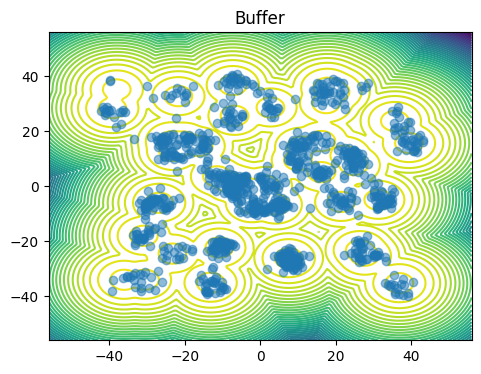

 22%|██▏       | 22/100 [02:57<10:27,  8.05s/it]

Epoch 22 | Time 0.000000 | Loss -199.644043
Epoch 22 | Time 0.001953 | Loss -203.872574
Epoch 22 | Time 0.003906 | Loss -224.169373
Epoch 22 | Time 0.005859 | Loss -248.108337
Epoch 22 | Time 0.007812 | Loss -273.616791
Epoch 22 | Time 0.009766 | Loss -273.007141
Epoch 22 | Time 0.011719 | Loss -269.605225
Epoch 22 | Time 0.013672 | Loss -266.537598
Epoch 22 | Time 0.015625 | Loss -226.222046
Epoch 22 | Time 0.017578 | Loss -193.488968
Epoch 22 | Time 0.019531 | Loss -170.913025
Epoch 22 | Time 0.021484 | Loss -186.404358
Epoch 22 | Time 0.023438 | Loss -168.979233
Epoch 22 | Time 0.025391 | Loss -156.233856
Epoch 22 | Time 0.027344 | Loss -137.300140
Epoch 22 | Time 0.029297 | Loss -108.786102
Epoch 22 | Time 0.031250 | Loss -80.470467
Epoch 22 | Time 0.033203 | Loss -56.959713
Epoch 22 | Time 0.035156 | Loss -44.746845
Epoch 22 | Time 0.037109 | Loss -72.914330
Epoch 22 | Time 0.039062 | Loss -81.182335
Epoch 22 | Time 0.041016 | Loss -79.582932
Epoch 22 | Time 0.042969 | Loss -55.08

In [ ]:
epsilon = 1e-6
reverse_ode = ReverseODE(vectorfield, noise_schedule, prior=prior, target=target, clipper=clipper, schedule=schedule)
num_samples = 1_024
outer_epochs = 100
inner_epochs = 2
beta = 1.0
lagrange_multiplier = 1.0

for epoch in tqdm(range(outer_epochs)):
    target = GMM(dimensionality=2,
             n_mixes=40,
             loc_scaling= 40,
             log_var_scaling=1.0,
             device=device,
             should_unnormalize=True)

    total_loss = 0.
    start_time = torch.tensor(0.0).to(device)
    delta = t_end - start_time
    num_integration_steps = int(torch.abs(delta) / dt)
    times = torch.linspace(start_time, t_end, num_integration_steps + 1)[:-1]
    indices = torch.arange(times.shape[0]).to(device)
    langevin_sde = LangevinSDE(beta=beta, prior=prior, target=target, vel=vectorfield, clipper=clipper, schedule=schedule)
    x_gen = langevin_sde.sample(x0=None, dt=dt, end_time=t_end, device=device, num_samples=1_024, compute_weight=False).detach()
    
    for i, t in zip(indices, times):
            optimizer.zero_grad()
            x = x_gen[i].to(device).detach()
            t = t.to(device).detach()
            loss = compute_pf_loss(x, t, schedule, target, prior, vectorfield,
                                    lagrange_multiplier, compute_kinetic_energy=True)
            loss = loss.mean()
            total_loss += loss.item()
            loss.backward()
            optimizer.step()

            print("Epoch %d | Time %f | Loss %f" % (epoch, t.item(), loss.item()))

    # Generate samples using the network
    samples = generate_samples_ode(reverse_ode, 1_024)
    samples_energy = target(samples)
    target.get_dataset_fig(target.unnormalize(samples))
    plt.show()


In [ ]:
target = GMM(dimensionality=2,
            n_mixes=40,
            loc_scaling= 40,
            log_var_scaling=1.0,
            device=device,
            should_unnormalize=True)
reverse_ode = ReverseODE(vectorfield, noise_schedule, prior=prior, target=target, clipper=clipper, schedule=schedule, resample_threshold=0.98)

dt = torch.tensor(1.0 / 512).to(device)
t_init,t_end = torch.tensor(0.0).to(device), torch.tensor(1.0).to(device)
# samples = reverse_ode.sample(x0=None, dt=dt, end_time=t_end, device=device, num_samples=1_000, compute_weight=False)[-1]
samples = generate_samples_ode(reverse_ode, 1_024)
samples_energy = target(samples)
target.get_dataset_fig(target.unnormalize(samples))
plt.show()

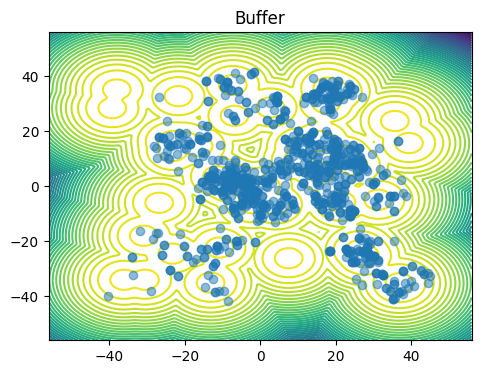

In [14]:
target = GMM(dimensionality=2,
            n_mixes=40,
            loc_scaling= 40,
            log_var_scaling=1.0,
            device=device,
            should_unnormalize=True)
langevin_sde = LangevinSDE(beta=beta, prior=prior, target=target, clipper=clipper, vel=vectorfield, schedule=schedule, resample_threshold=0.98)

dt = torch.tensor(1.0 / 512).to(device)
t_init,t_end = torch.tensor(0.0).to(device), torch.tensor(1.0).to(device)
samples = langevin_sde.sample(x0=None, dt=dt, end_time=t_end, device=device, num_samples=1_000, compute_weight=True)
samples_energy = target(samples[-1])
target.get_dataset_fig(target.unnormalize(samples[-1]))
plt.show()